# 라이브러리 설치

In [1]:
!python -m pip install numpy pandas matplotlib seaborn folium

# 라이브러리 임포트

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [3]:
plt.rc('font', family='Malgun Gothic') # 'Apple Gothic'
plt.rc('axes', unicode_minus=False)

# 데이터를 읽어들여 데이터 프레임 만들기

In [4]:
bike_temp = pd.read_csv('../data/bike_rent_1.csv', encoding='cp949', parse_dates=['대여일시'])
bike_temp.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930


In [5]:
bike_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 399999 entries, 0 to 399998
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   자전거번호     399999 non-null  str           
 1   대여일시      399999 non-null  datetime64[us]
 2   대여 대여소번호  399999 non-null  int64         
 3   대여 대여소명   399999 non-null  str           
 4   이용시간      399999 non-null  int64         
 5   이용거리      399999 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 18.3 MB


In [6]:
bike_dictionary = {}

for file_number in range(1, 7):
    file_name = f'../data/bike_rent_{file_number}.csv'
    bike_csv = pd.read_csv(file_name, encoding='cp949', parse_dates=['대여일시'])
    bike_dictionary[file_number] = bike_csv

In [7]:
bike_dictionary

{1:             자전거번호                대여일시  대여 대여소번호            대여 대여소명  이용시간  이용거리
 0       SPB-22040 2019-06-03 08:49:00       646  장한평역 1번출구 (국민은행앞)    27  1330
 1       SPB-07446 2019-06-03 08:33:00       526           용답토속공원 앞    54  1180
 2       SPB-20387 2019-06-05 08:27:00       646  장한평역 1번출구 (국민은행앞)    12  1930
 3       SPB-16794 2019-06-05 08:46:00       646  장한평역 1번출구 (국민은행앞)     6  1340
 4       SPB-18266 2019-06-10 08:27:00       529       장한평역 8번 출구 앞     5  1230
 ...           ...                 ...       ...                ...   ...   ...
 399994  SPB-16680 2019-06-28 17:14:00       316         종각역 1번출구 앞    16  2360
 399995  SPB-07874 2019-06-28 16:59:00       345         서울보증보험본사 앞    32  1880
 399996  SPB-21622 2019-06-28 16:44:00       526           용답토속공원 앞    64  6100
 399997  SPB-20056 2019-06-28 17:46:00       453  종로오가 지하쇼핑센터 14번출구     7   880
 399998  SPB-18692 2019-06-28 17:34:00       345         서울보증보험본사 앞    35  1820
 
 [399999 rows x 6 columns],
 2:    

In [8]:
print(type(bike_dictionary), type(bike_dictionary[1]))

<class 'dict'> <class 'pandas.DataFrame'>


In [9]:
# DataFrame 합치기 (concat)
# ignore_index 기존 인덱스를 무시하고 다시 순서를 0 부터 생성한다.
bikes = pd.concat(bike_dictionary, ignore_index=True)
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [10]:
bikes.tail()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030
2215631,SPB-14209,2019-06-28 07:37:00,240,문래역 4번출구 앞,6,1010


# 깃허브 코파일럿이 만들어준 코드

In [11]:
from pathlib import Path

# Gather bike_rent CSV files and read them into DataFrames
files = sorted(Path('../data').glob('bike_rent_*.csv'))
files

[WindowsPath('../data/bike_rent_1.csv'),
 WindowsPath('../data/bike_rent_2.csv'),
 WindowsPath('../data/bike_rent_3.csv'),
 WindowsPath('../data/bike_rent_4.csv'),
 WindowsPath('../data/bike_rent_5.csv'),
 WindowsPath('../data/bike_rent_6.csv')]

In [12]:
dfs = [pd.read_csv(f, encoding='cp949', parse_dates=['대여일시']) for f in files]
# Concatenate into a single DataFrame
bike_rent_df = pd.concat(dfs, ignore_index=True)
print('Combined rows:', bike_rent_df.shape[0])
bike_rent_df.head()

Combined rows: 2215632


,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [13]:
bike_rent_df.tail()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030
2215631,SPB-14209,2019-06-28 07:37:00,240,문래역 4번출구 앞,6,1010


# 데이터 프레임 관찰

In [14]:
bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2215632 entries, 0 to 2215631
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     str           
 1   대여일시      datetime64[us]
 2   대여 대여소번호  int64         
 3   대여 대여소명   str           
 4   이용시간      int64         
 5   이용거리      int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 101.4 MB


In [15]:
bikes.shape

(2215632, 6)

In [16]:
bikes.describe()

,대여일시,대여 대여소번호,이용시간,이용거리
count,2215632,2.215632e+06,2.215632e+06,2.215632e+06
mean,2019-06-16 08:40:01.500303,1.226154e+03,2.716998e+01,3.912916e+03
min,2019-06-01 00:00:00,3.000000e+00,1.000000e+00,0.000000e+00
25%,2019-06-08 22:04:00,5.050000e+02,8.000000e+00,1.220000e+03
50%,2019-06-16 15:13:00,1.159000e+03,1.700000e+01,2.270000e+03
75%,2019-06-23 20:22:00,1.846000e+03,3.700000e+01,4.670000e+03
max,2019-06-30 23:59:00,9.998000e+03,3.133000e+03,2.323100e+05
std,NaN,8.499197e+02,2.908119e+01,5.145471e+03


In [17]:
bikes.index

RangeIndex(start=0, stop=2215632, step=1)

In [18]:
bikes.columns

Index(['자전거번호', '대여일시', '대여 대여소번호', '대여 대여소명', '이용시간', '이용거리'], dtype='str')

In [19]:
bikes.dtypes

자전거번호                  str
대여일시        datetime64[us]
대여 대여소번호             int64
대여 대여소명                str
이용시간                 int64
이용거리                 int64
dtype: object

In [20]:
pd.options.display.float_format='{:.2f}'.format

In [21]:
bikes.isnull()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
2215627,False,False,False,False,False,False
2215628,False,False,False,False,False,False
2215629,False,False,False,False,False,False
2215630,False,False,False,False,False,False


In [22]:
bikes.isnull().sum()

자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
dtype: int64

# 날짜와 시간 계산을 위한 새로운 컬럼 추가

In [23]:
bikes['대여일시'].head()

0   2019-06-03 08:49:00
1   2019-06-03 08:33:00
2   2019-06-05 08:27:00
3   2019-06-05 08:46:00
4   2019-06-10 08:27:00
Name: 대여일시, dtype: datetime64[us]

In [25]:
bikes['대여일시'].dt.day.head()

0     3
1     3
2     5
3     5
4    10
Name: 대여일시, dtype: int32

In [26]:
bikes['일자'] = bikes['대여일시'].dt.day
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10


In [27]:
bikes['대여일시'].dt.hour.head()

0    8
1    8
2    8
3    8
4    8
Name: 대여일시, dtype: int32

In [28]:
bikes['대여시간대'] = bikes['대여일시'].dt.hour
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8


In [ ]:
bikes['대여일시'].dt.dayofweek.head()

0    0
1    0
2    2
3    2
4    0
Name: 대여일시, dtype: int32

In [30]:
bikes['대여일시'].dt.day_of_week.head()

0    0
1    0
2    2
3    2
4    0
Name: 대여일시, dtype: int32

In [31]:
# 월요일 : 0, 화요일 : 1 ...
weeks = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

In [32]:
bikes['대여일시'].dt.dayofweek.apply(lambda x: weeks[x]).head()

0    월
1    월
2    수
3    수
4    월
Name: 대여일시, dtype: str

In [33]:
# 대여일시에서 dayofweek 을 추출해서 요일 컬럼으로 추가하기
# 이때 요일이 숫자이므로 요일 이름으로 변환해서 추가
bikes['요일'] = bikes['대여일시'].dt.dayofweek.apply(lambda x: weeks[x])
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월


In [34]:
bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말').head()

0    평일
1    평일
2    평일
3    평일
4    평일
Name: 대여일시, dtype: str

In [35]:
temp1 = bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')
temp1.head()

0    평일
1    평일
2    평일
3    평일
4    평일
Name: 대여일시, dtype: str

In [36]:
temp1[temp1 == '주말']

23         주말
32         주말
33         주말
34         주말
35         주말
           ..
2215590    주말
2215591    주말
2215614    주말
2215615    주말
2215619    주말
Name: 대여일시, Length: 737033, dtype: str

In [38]:
bikes.iloc[23]

자전거번호                 SPB-23160
대여일시        2019-06-16 07:27:00
대여 대여소번호                    704
대여 대여소명             남부법원검찰청 교차로
이용시간                         31
이용거리                       6700
일자                           16
대여시간대                         7
요일                            일
Name: 23, dtype: object

In [63]:
# 토요일 검색
(bikes[bikes['요일'] == '토']).head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
32,SPB-20336,2019-06-29 21:05:00,207,여의나루역 1번출구 앞,48,12560,29,21,토,주말
33,SPB-16935,2019-06-29 23:18:00,259,대방역6번출구,7,1590,29,23,토,주말
34,SPB-24672,2019-06-29 23:10:00,207,여의나루역 1번출구 앞,54,7940,29,23,토,주말


In [44]:
bikes['주말구분'] = bikes['대여일시'].dt.dayofweek.apply(lambda x: '평일' if x < 5 else '주말')
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일


# 장소적 특성에 따른 컬럼 추가

In [46]:
bike_shop = pd.read_csv('../data/bike_shop.csv', encoding='cp949')
bike_shop.head(3)

,구분,대여소번호,대여소명,위도,경도,거치대수
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91,5
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91,20
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91,14


In [47]:
bike_shop.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      1537 non-null   str    
 1   대여소번호   1537 non-null   int64  
 2   대여소명    1537 non-null   str    
 3   위도      1537 non-null   float64
 4   경도      1537 non-null   float64
 5   거치대수    1537 non-null   int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 72.2 KB


In [48]:
bike_shop[['구분', '대여소번호', '대여소명', '위도', '경도']]

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91
...,...,...,...,...,...
1532,광진구,3537,아차산 휴먼시아 아파트 옆,37.55,127.09
1533,성동구,3538,서울숲 IT캐슬,37.55,127.04
1534,강동구,3539,서원마을,37.56,127.13
1535,광진구,3541,커먼그라운드,37.55,127.09


In [50]:
bike_shop.drop('거치대수', axis=1)

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91
...,...,...,...,...,...
1532,광진구,3537,아차산 휴먼시아 아파트 옆,37.55,127.09
1533,성동구,3538,서울숲 IT캐슬,37.55,127.04
1534,강동구,3539,서원마을,37.56,127.13
1535,광진구,3541,커먼그라운드,37.55,127.09


In [51]:
bike_shop.head(3)

,구분,대여소번호,대여소명,위도,경도,거치대수
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91,5
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91,20
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91,14


In [52]:
bike_gu = bike_shop.drop('거치대수', axis=1)
bike_gu.head()

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91


In [53]:
bikes_merged = pd.merge(bikes, bike_gu, left_on='대여 대여소번호', right_on='대여소번호')
bikes_merged.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,대여소번호,대여소명,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,526,526. 용답토속공원 앞,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06


In [54]:
bikes_dropped = bikes_merged.drop(['대여소번호', '대여소명'], axis=1)
bikes_dropped.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06


In [57]:
bikes_renamed = bikes_dropped.rename(columns={'구분': '대여구', '위도': '대여점위도', '경도': '대여점경도'})
bikes_renamed.head(3)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,대여구,대여점위도,대여점경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06


# 시간에 따른 시각화

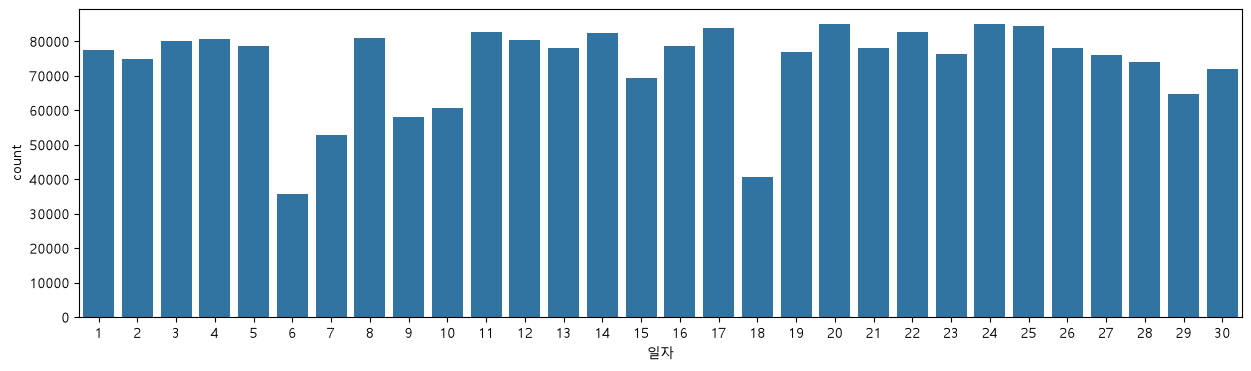

In [58]:
plt.figure(figsize=(15, 4))
sns.countplot(data=bikes_renamed, x='일자')
plt.show()

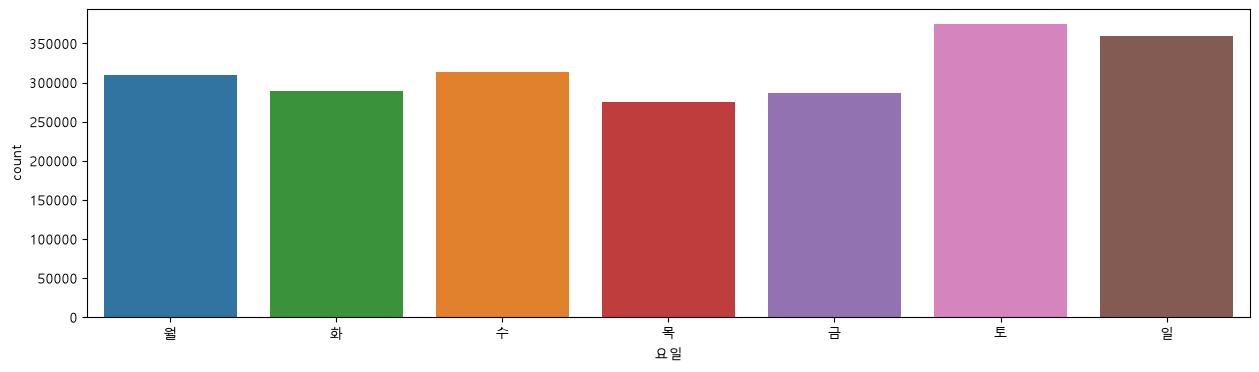

In [60]:
plt.figure(figsize=(15, 4))
sns.countplot(data=bikes_renamed, x='요일', hue='요일', order=['월', '화', '수', '목', '금', '토', '일'])
plt.show()